<a href="https://colab.research.google.com/github/agief-G1A024037/Kelompok-07-09-015-037-041-/blob/main/Bagian2No3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bagian 2 No. 3
### Mengapa KNN Membutuhkan Memori Lebih Besar Dibandingkan Decision Tree Saat Testing?
#### Hubungan dengan Konsep Non-Parametric Learner



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_folder = '/content/drive/MyDrive/KelompokAli'
os.makedirs(save_folder, exist_ok=True)

print(f'✅ Google Drive terhubung!')
print(f'📁 Folder: {save_folder}')

Mounted at /content/drive
✅ Google Drive terhubung!
📁 Folder: /content/drive/MyDrive/KelompokAli


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


In [3]:
np.random.seed(42)

cats_size   = np.random.normal(3.5, 0.8, 30)
cats_energy = np.random.normal(5.0, 1.2, 30)
cats_label  = np.zeros(30, dtype=int)

dogs_size   = np.random.normal(7.0, 1.5, 30)
dogs_energy = np.random.normal(7.5, 1.0, 30)
dogs_label  = np.ones(30, dtype=int)

unusual_size   = np.array([2.5])
unusual_energy = np.array([4.5])
unusual_label  = np.array([1])

X = np.column_stack([
    np.concatenate([cats_size, dogs_size, unusual_size]),
    np.concatenate([cats_energy, dogs_energy, unusual_energy])
])
y = np.concatenate([cats_label, dogs_label, unusual_label])
X = np.clip(X, 1, 10)

label_names = {0: 'Kucing', 1: 'Anjing'}

print(f'✅ Dataset: {len(y)} sampel')
print(f'   Kucing: {sum(y==0)} | Anjing: {sum(y==1)}')

✅ Dataset: 61 sampel
   Kucing: 30 | Anjing: 31


In [4]:
unusual_flag = ['Ya' if i == len(y)-1 else 'Tidak' for i in range(len(y))]

df_dataset = pd.DataFrame({
    'No'             : range(1, len(y)+1),
    'Ukuran_Tubuh'   : np.round(X[:,0], 3),
    'Tingkat_Energi' : np.round(X[:,1], 3),
    'Label_Angka'    : y,
    'Label_Nama'     : [label_names[i] for i in y],
    'Unusual_Token'  : unusual_flag
})

excel_path = f'{save_folder}/KNN_Dataset.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df_dataset.to_excel(writer, sheet_name='Dataset', index=False)

print(f'✅ Dataset disimpan ke Excel!')
print(df_dataset.head(10))

✅ Dataset disimpan ke Excel!
   No  Ukuran_Tubuh  Tingkat_Energi  Label_Angka Label_Nama Unusual_Token
0   1         3.897           4.278            0     Kucing         Tidak
1   2         3.389           7.223            0     Kucing         Tidak
2   3         4.018           4.984            0     Kucing         Tidak
3   4         4.718           3.731            0     Kucing         Tidak
4   5         3.313           5.987            0     Kucing         Tidak
5   6         3.313           3.535            0     Kucing         Tidak
6   7         4.763           5.251            0     Kucing         Tidak
7   8         4.114           2.648            0     Kucing         Tidak
8   9         3.124           3.406            0     Kucing         Tidak
9  10         3.934           5.236            0     Kucing         Tidak


In [5]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X, y)

knn_mem_bytes = X.nbytes + y.nbytes
knn_mem_kb    = knn_mem_bytes / 1024

print('='*60)
print('  BAGIAN 2 NO.3 — ANALISIS MEMORI KNN SAAT TESTING')
print('='*60)

print(f'\n🔵 KNN adalah NON-PARAMETRIC LEARNER')
print(f'   Tidak ada parameter yang merangkum hasil belajar.')
print(f'   Data training ADALAH modelnya.')
print()
print(f'   Yang harus disimpan saat testing:')
print(f'   → Seluruh data X : {X.nbytes} bytes')
print(f'   → Seluruh label y: {y.nbytes} bytes')
print(f'   → TOTAL          : {knn_mem_bytes} bytes ({knn_mem_kb:.2f} KB)')
print()
print(f'   Cara kerja saat testing:')
print(f'   1. Terima data uji baru')
print(f'   2. Hitung jarak ke SEMUA {len(y)} data training')
print(f'   3. Ambil {knn_model.n_neighbors} tetangga terdekat')
print(f'   4. Voting → tentukan label')
print()
print(f'   ⚠️  Jika data training dibuang → KNN tidak bisa bekerja!')

  BAGIAN 2 NO.3 — ANALISIS MEMORI KNN SAAT TESTING

🔵 KNN adalah NON-PARAMETRIC LEARNER
   Tidak ada parameter yang merangkum hasil belajar.
   Data training ADALAH modelnya.

   Yang harus disimpan saat testing:
   → Seluruh data X : 976 bytes
   → Seluruh label y: 488 bytes
   → TOTAL          : 1464 bytes (1.43 KB)

   Cara kerja saat testing:
   1. Terima data uji baru
   2. Hitung jarak ke SEMUA 61 data training
   3. Ambil 3 tetangga terdekat
   4. Voting → tentukan label

   ⚠️  Jika data training dibuang → KNN tidak bisa bekerja!


In [6]:
test_point = np.array([[3.2, 4.8]])

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X, y)

# Cari 3 tetangga terdekat
distances, indices = knn_model.kneighbors(test_point)

print('='*60)
print('  BUKTI KNN MENGGUNAKAN SELURUH DATA TRAINING')
print('='*60)
print(f'\n  Test Point: Ukuran={test_point[0,0]}, Energi={test_point[0,1]}')
print(f'\n  KNN menghitung jarak ke SEMUA {len(y)} data training...')
print(f'  Lalu memilih {knn_model.n_neighbors} tetangga terdekat:\n')
print(f'  {"Rank":<6} {"Index Data":<12} {"Ukuran":<10} {"Energi":<10} {"Label":<10} {"Jarak":<10}')
print('  ' + '-'*55)

for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    print(f'  {rank:<6} {idx:<12} {X[idx,0]:<10.3f} {X[idx,1]:<10.3f} '
          f'{label_names[y[idx]]:<10} {dist:<10.4f}')

pred = knn_model.predict(test_point)[0]
print(f'\n  Hasil voting → Prediksi: {label_names[pred]}')
print(f'\n  💡 Tanpa menyimpan semua {len(y)} data training,')
print(f'     KNN tidak bisa mencari tetangga terdekat!')

  BUKTI KNN MENGGUNAKAN SELURUH DATA TRAINING

  Test Point: Ukuran=3.2, Energi=4.8

  KNN menghitung jarak ke SEMUA 61 data training...
  Lalu memilih 3 tetangga terdekat:

  Rank   Index Data   Ukuran     Energi     Label      Jarak     
  -------------------------------------------------------
  1      21           3.319      4.538      Kucing     0.2880    
  2      11           3.127      5.206      Kucing     0.4121    
  3      12           3.694      4.861      Kucing     0.4974    

  Hasil voting → Prediksi: Kucing

  💡 Tanpa menyimpan semua 61 data training,
     KNN tidak bisa mencari tetangga terdekat!


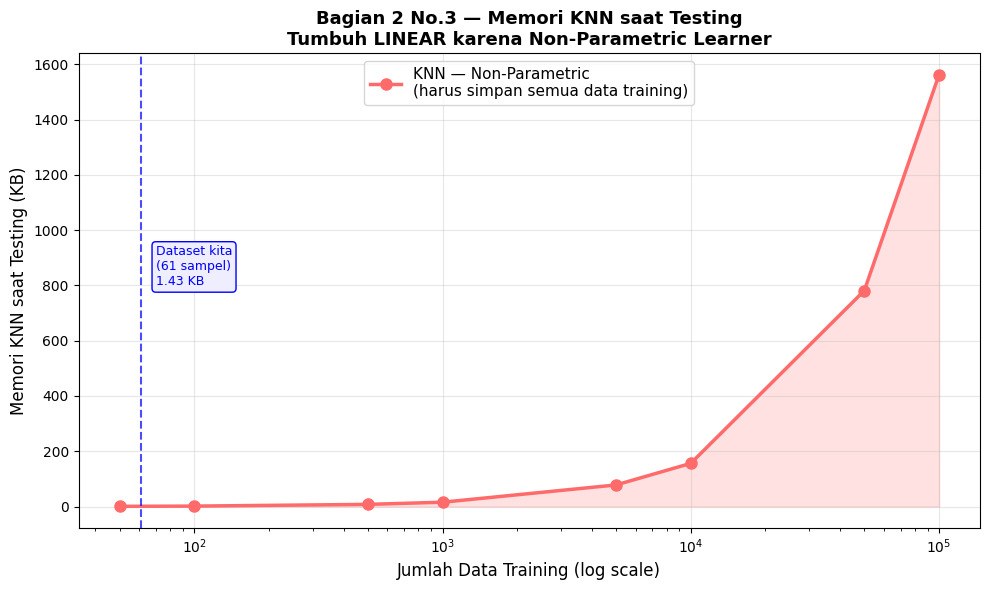

✅ Grafik disimpan!


In [7]:
sizes        = [50, 100, 500, 1000, 5000, 10000, 50000, 100000]
knn_mem_list = [n * 2 * 8 for n in sizes]   # linear growth

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizes, [m/1024 for m in knn_mem_list],
        'o-', color='#FF6B6B', linewidth=2.5, markersize=8,
        label='KNN — Non-Parametric\n(harus simpan semua data training)')
ax.fill_between(sizes, [m/1024 for m in knn_mem_list],
                alpha=0.2, color='#FF6B6B')

# Tandai posisi dataset kita (61 sampel)
ax.axvline(x=61, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(70, 800, f'Dataset kita\n({len(y)} sampel)\n{knn_mem_kb:.2f} KB',
        fontsize=9, color='blue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#EEF', edgecolor='blue'))

ax.set_xscale('log')
ax.set_xlabel('Jumlah Data Training (log scale)', fontsize=12)
ax.set_ylabel('Memori KNN saat Testing (KB)', fontsize=12)
ax.set_title('Bagian 2 No.3 — Memori KNN saat Testing\n'
             'Tumbuh LINEAR karena Non-Parametric Learner',
             fontsize=13, fontweight='bold')
ax.annotate('Semakin banyak data\n→ semakin besar memori\n(LINEAR GROWTH)',
            xy=(50000, 7500), fontsize=10, color='#CC3333',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#FFEEEE', edgecolor='#CC3333'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_folder}/grafik_memori_knn_no3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan!')

In [8]:
df_memori_knn = pd.DataFrame({
    'Jumlah_Data_Training'  : sizes,
    'Memori_KNN_bytes'      : knn_mem_list,
    'Memori_KNN_KB'         : [round(m/1024, 2) for m in knn_mem_list],
    'Keterangan'            : ['Non-Parametric: simpan semua data'] * len(sizes)
})

# Tabel tetangga terdekat
rows_knn = []
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    rows_knn.append({
        'Rank'          : rank,
        'Index_Data'    : idx,
        'Ukuran_Tubuh'  : round(X[idx,0], 3),
        'Tingkat_Energi': round(X[idx,1], 3),
        'Label'         : label_names[y[idx]],
        'Jarak'         : round(dist, 4)
    })
df_knn_result = pd.DataFrame(rows_knn)

excel_path2 = f'{save_folder}/KNN_Hasil_No3.xlsx'
with pd.ExcelWriter(excel_path2, engine='openpyxl') as writer:
    df_dataset.to_excel(writer,    sheet_name='Dataset',         index=False)
    df_knn_result.to_excel(writer, sheet_name='Tetangga_Terdekat', index=False)
    df_memori_knn.to_excel(writer, sheet_name='Memori_KNN',      index=False)

print(f'✅ Excel disimpan: {excel_path2}')
print()
print('📋 Sheet 1 → Dataset           : data training lengkap')
print('📋 Sheet 2 → Tetangga_Terdekat : hasil pencarian KNN')
print('📋 Sheet 3 → Memori_KNN        : pertumbuhan memori KNN')

# Download
from google.colab import files
files.download(excel_path2)
print('\n✅ File didownload!')

✅ Excel disimpan: /content/drive/MyDrive/KelompokAli/KNN_Hasil_No3.xlsx

📋 Sheet 1 → Dataset           : data training lengkap
📋 Sheet 2 → Tetangga_Terdekat : hasil pencarian KNN
📋 Sheet 3 → Memori_KNN        : pertumbuhan memori KNN


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File didownload!
